<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML__Assignment_02_Case_Study_01_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment-2


#CASE STUDY 01
#Preprocessing

Dataset for loan prediction is given
1. Load the dataset in Python environment
2. Perform different preprocessing steps
   -  Missing value handling
   - Outlier detection
   - Encoding
   - Scaling
3. Give detailed description for each step

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1. Loading the data

In [33]:
df=pd.read_csv('/content/train_loan.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


#2. shape of the data

In [34]:
df.shape

(614, 13)

# 3. Checking the first few rows

In [35]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# 4. checking summary of the dataframe

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Object/categorical columns
1. Load ID
2. Gender
3. Married
4. Dependents
5. Education
6. Self_Employed


12. Property_Area
13. Loan_Status  (target column)

## Numerical columns

 7. ApplicantIncome     
 8. CoapplicantIncome  
 9. LoanAmount         
 10. Loan_Amount_Term   
 11. Credit_History        


#4. Checking the summary statistics of the dataframe

In [37]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


#6. Columns in the dataset

In [38]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

#7. Identifying and count the missing values in dataframe

In [39]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


# Missing values in categorical column:

1. Gender	13 (Male,Female)
2. Married	3 (Yes,No)
3. Dependents	15 (0,1,2,3+)
4. Self_Employed 32 (Yes,No)

# Missing values in numerical columns

1. LoanAmount	 22
2. Loan_Amount_Term 	14
3. Credit_History 	50

In [40]:
df.nunique()

,0
Loan_ID,614
Gender,2
Married,2
Dependents,4
Education,2
Self_Employed,2
ApplicantIncome,505
CoapplicantIncome,287
LoanAmount,203
Loan_Amount_Term,10


In [41]:
df.value_counts()

,,,,,,,,,,,,,count
Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,
LP002936,Male,Yes,0,Graduate,No,3859,3300.0,142.0,180.0,1.0,Rural,Y,1
LP002931,Male,Yes,2,Graduate,Yes,6000,0.0,205.0,240.0,1.0,Semiurban,N,1
LP002928,Male,Yes,0,Graduate,No,3000,3416.0,56.0,180.0,1.0,Semiurban,Y,1
LP002926,Male,Yes,2,Graduate,Yes,2726,0.0,106.0,360.0,0.0,Semiurban,N,1
LP002917,Female,No,0,Not Graduate,No,2165,0.0,70.0,360.0,1.0,Semiurban,Y,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,1
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,1
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,1


In [42]:
df['Gender'].value_counts()

,count
Gender,
Male,489
Female,112


In [43]:
df['Married'].value_counts()

,count
Married,
Yes,398
No,213


In [44]:
print(df['Dependents'].value_counts())

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64


In [45]:
df['Self_Employed'].value_counts()

,count
Self_Employed,
No,500
Yes,82


# 8. Outlier checking

In [46]:
# prompt: plt.xticks(angle=90)

import matplotlib.pyplot as plt



(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'ApplicantIncome'),
  Text(2, 0, 'CoapplicantIncome'),
  Text(3, 0, 'LoanAmount'),
  Text(4, 0, 'Loan_Amount_Term'),
  Text(5, 0, 'Credit_History')])

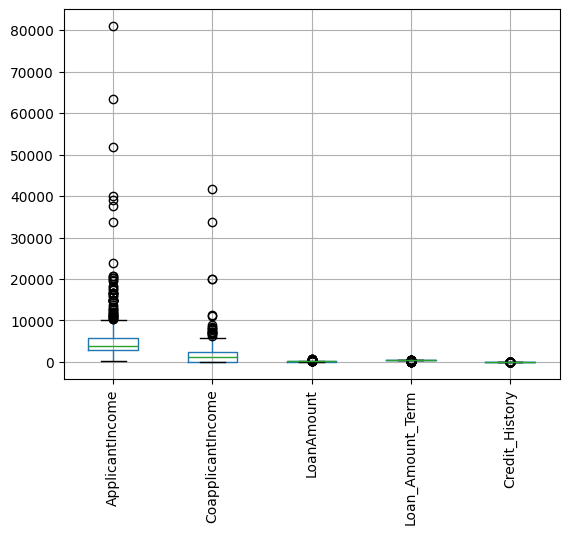

In [47]:
df.boxplot()
plt.xticks(rotation=90)

There are outliers in Applicanticome and Coapplicantincome

# 9. Fill missing values in categorical column using mode

In [48]:
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

# 10. Fill missing values in numerical column using mode

In [49]:
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    df[col] = df[col].fillna(df[col].mode()[0])

#11. Check missing values again

In [50]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


## All missing vaues are filled

# 12. Handling outliers

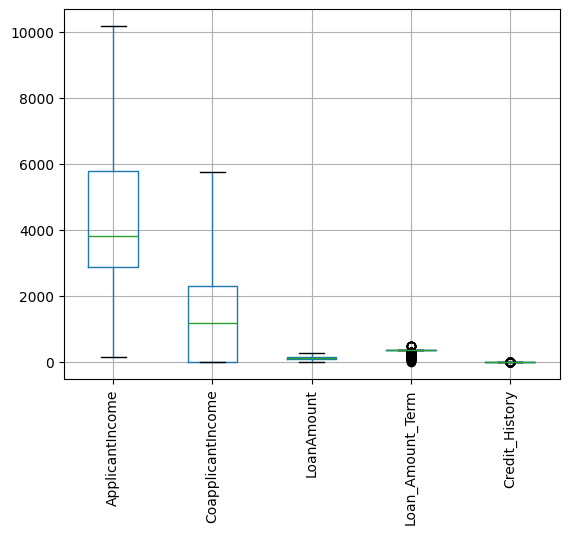

In [51]:
# Function to handle outliers using IQR method
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replacing outliers with the upper and lower bounds
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df


# Apply outlier handling to 'ApplicantIncome' and 'CoapplicantIncome'
df = handle_outliers(df, 'ApplicantIncome')
df = handle_outliers(df, 'CoapplicantIncome')
df = handle_outliers(df, 'LoanAmount')


# Recheck for outliers (Optional)
df.boxplot()
plt.xticks(rotation=90)
plt.show()


# ... (Rest of your existing code)


# 13. Applying Encoding

In [52]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns (replace with your actual column names)
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

# Create a OneHotEncoder object
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # sparse=False for dense output

# Fit the encoder on the categorical columns
encoder.fit(df[categorical_cols])

# Transform the categorical features into one-hot encoded features
encoded_features = encoder.transform(df[categorical_cols])

# Create a new DataFrame with the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))


# Concatenate the encoded features with the original DataFrame (excluding the original categorical columns)
df_encoded = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

# Now 'df_encoded' contains your data with one-hot encoded features
print(df_encoded.head())

    Loan_ID  ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0  LP001002           5849.0                0.0       120.0             360.0   
1  LP001003           4583.0             1508.0       128.0             360.0   
2  LP001005           3000.0                0.0        66.0             360.0   
3  LP001006           2583.0             2358.0       120.0             360.0   
4  LP001008           6000.0                0.0       141.0             360.0   

   Credit_History  Gender_Female  Gender_Male  Married_No  Married_Yes  ...  \
0             1.0            0.0          1.0         1.0          0.0  ...   
1             1.0            0.0          1.0         0.0          1.0  ...   
2             1.0            0.0          1.0         0.0          1.0  ...   
3             1.0            0.0          1.0         0.0          1.0  ...   
4             1.0            0.0          1.0         1.0          0.0  ...   

   Dependents_3+  Education_Graduate  

# 14. Apply min max scaling

In [53]:
from sklearn.preprocessing import MinMaxScaler

# Assuming 'df_encoded' is your DataFrame after one-hot encoding
# Select numerical columns for scaling (replace with your actual numerical column names)
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Fit and transform the numerical columns
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Now 'df_encoded' contains your data with min-max scaled numerical features
print(df_encoded.head())

    Loan_ID  ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0  LP001002         0.568692           0.000000    0.439604           0.74359   
1  LP001003         0.442360           0.262575    0.471287           0.74359   
2  LP001005         0.284396           0.000000    0.225743           0.74359   
3  LP001006         0.242784           0.410578    0.439604           0.74359   
4  LP001008         0.583760           0.000000    0.522772           0.74359   

   Credit_History  Gender_Female  Gender_Male  Married_No  Married_Yes  ...  \
0             1.0            0.0          1.0         1.0          0.0  ...   
1             1.0            0.0          1.0         0.0          1.0  ...   
2             1.0            0.0          1.0         0.0          1.0  ...   
3             1.0            0.0          1.0         0.0          1.0  ...   
4             1.0            0.0          1.0         1.0          0.0  ...   

   Dependents_3+  Education_Graduate  